In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

conn = sqlite3.connect("../data/vayu_clean.db")
df = pd.read_sql("SELECT * FROM features", conn, parse_dates=["timestamp"])
conn.close()

print(df.shape)
df.info()
df.head()

(127011, 27)
<class 'pandas.DataFrame'>
RangeIndex: 127011 entries, 0 to 127010
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 127011 non-null  int64         
 1   city               127011 non-null  str           
 2   latitude           127011 non-null  float64       
 3   longitude          127011 non-null  float64       
 4   aqi                127011 non-null  int64         
 5   pm25               127011 non-null  float64       
 6   pm10               127011 non-null  float64       
 7   no2                127011 non-null  float64       
 8   o3                 127011 non-null  float64       
 9   timestamp          127011 non-null  datetime64[us]
 10  fetched_at         127011 non-null  str           
 11  temperature_c      127011 non-null  float64       
 12  humidity_pct       127011 non-null  float64       
 13  wind_speed_ms      104691 non-null  float6

,id,city,latitude,longitude,aqi,pm25,pm10,no2,o3,timestamp,...,day_of_week,month,is_weekend,aqi_lag_1h,aqi_lag_3h,aqi_lag_24h,aqi_roll_6h,aqi_roll_24h,next_aqi,next_aqi_category
0,1,Ahmedabad,23.0225,72.5714,2,7.97,21.41,2.81,36.80,2025-07-01 19:00:00,...,1,7,0,NaN,NaN,NaN,2.0,2.0,1.0,Good
1,2,Ahmedabad,23.0225,72.5714,2,8.34,23.98,2.52,36.52,2025-07-01 20:00:00,...,1,7,0,2.0,NaN,NaN,2.0,2.0,1.0,Good
2,3,Ahmedabad,23.0225,72.5714,2,8.49,25.07,2.28,36.21,2025-07-01 21:00:00,...,1,7,0,2.0,NaN,NaN,2.0,2.0,1.0,Good
3,4,Ahmedabad,23.0225,72.5714,2,8.42,24.39,2.09,35.74,2025-07-01 22:00:00,...,1,7,0,2.0,2.0,NaN,2.0,2.0,1.0,Good
4,5,Ahmedabad,23.0225,72.5714,2,8.16,22.49,1.97,35.34,2025-07-01 23:00:00,...,1,7,0,2.0,2.0,NaN,2.0,2.0,1.0,Good


In [2]:
df.describe()[["aqi", "pm25", "pm10", "no2", "o3", "temperature_c", "wind_speed_ms"]]

,aqi,pm25,pm10,no2,o3,temperature_c,wind_speed_ms
count,127011.000000,127011.000000,127011.000000,127011.000000,127011.000000,127011.000000,104691.000000
mean,2.990599,51.713793,64.831774,6.303608,71.410103,25.231212,2.339734
min,1.000000,0.000000,0.000000,0.030000,0.000000,3.200000,0.000000
25%,2.000000,10.890000,16.240000,1.940000,35.890000,21.600000,1.410000
50%,3.000000,30.820000,45.460000,4.700000,61.230000,25.800000,2.190000
75%,4.000000,70.230000,90.150000,8.870000,99.000000,29.100000,3.080000
max,5.000000,675.850000,684.660000,58.830000,280.930000,44.100000,10.120000
std,1.443290,60.694770,66.567921,5.871588,44.768026,6.085961,1.263484


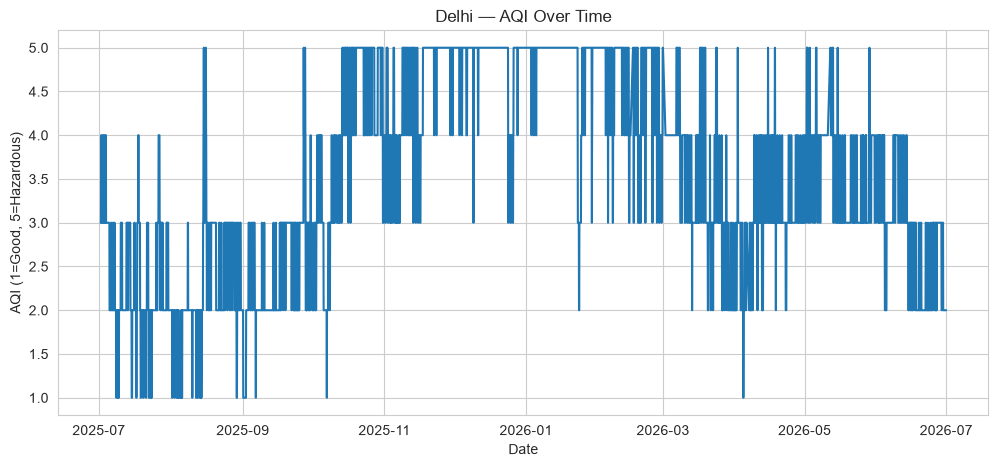

In [3]:
delhi = df[df["city"] == "Delhi"].sort_values("timestamp")

plt.plot(delhi["timestamp"], delhi["aqi"])
plt.title("Delhi — AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI (1=Good, 5=Hazardous)")
plt.show()

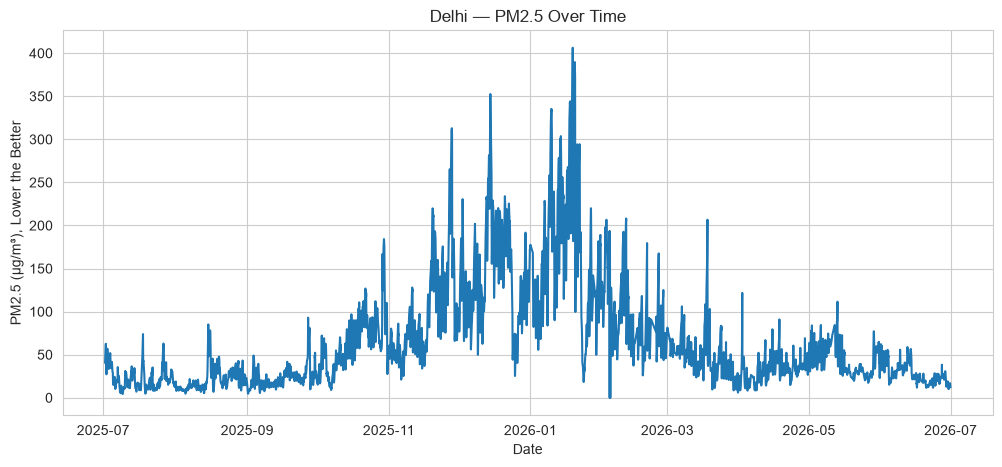

In [4]:
delhi = df[df["city"] == "Delhi"].sort_values("timestamp")

plt.plot(delhi["timestamp"], delhi["pm25"])
plt.title("Delhi — PM2.5 Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³), Lower the Better")
plt.show()

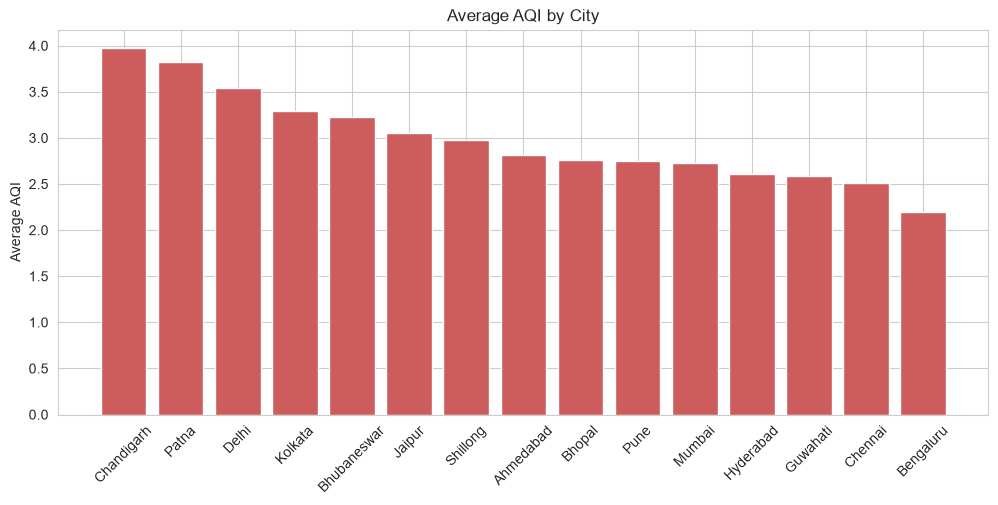

city
Chandigarh     3.976103
Patna          3.819472
Delhi          3.542766
Kolkata        3.291023
Bhubaneswar    3.226074
Jaipur         3.055483
Shillong       2.980064
Ahmedabad      2.816610
Bhopal         2.755590
Pune           2.752735
Mumbai         2.728267
Hyderabad      2.612445
Guwahati       2.590185
Chennai        2.515675
Bengaluru      2.200639
Name: aqi, dtype: float64

In [5]:
city_avg = df.groupby("city")["aqi"].mean().sort_values(ascending=False)

plt.bar(city_avg.index, city_avg.values, color="indianred")
plt.title("Average AQI by City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.show()

city_avg

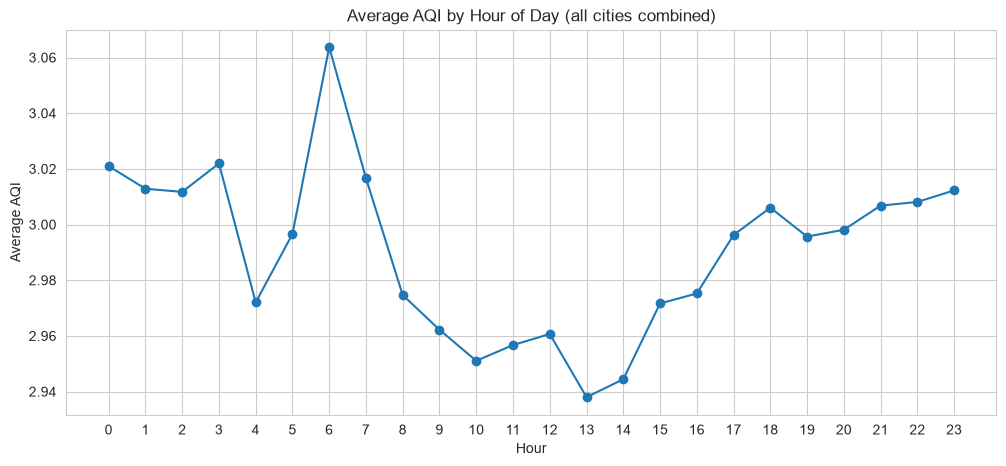

In [6]:
hourly_avg = df.groupby("hour")["aqi"].mean()

plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average AQI by Hour of Day (all cities combined)")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.show()

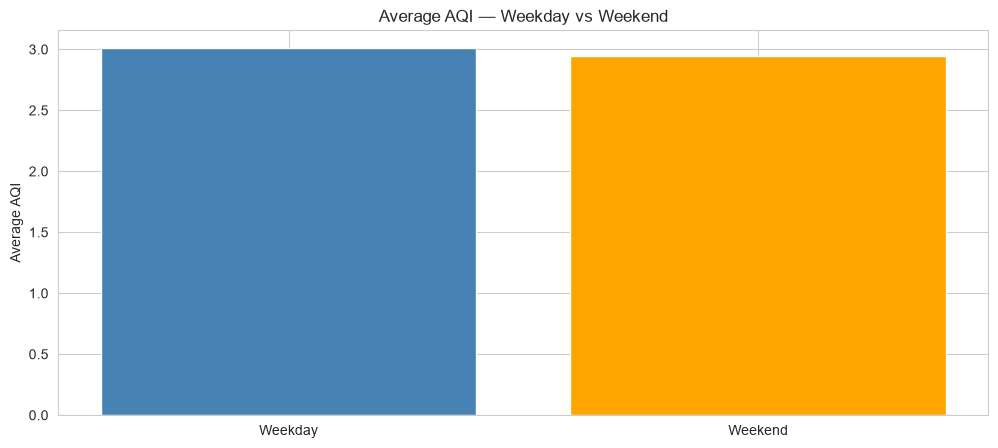

In [7]:
weekend_avg = df.groupby("is_weekend")["aqi"].mean()
weekend_avg.index = ["Weekday", "Weekend"]

plt.bar(weekend_avg.index, weekend_avg.values, color=["steelblue", "orange"])
plt.title("Average AQI — Weekday vs Weekend")
plt.ylabel("Average AQI")
plt.show()

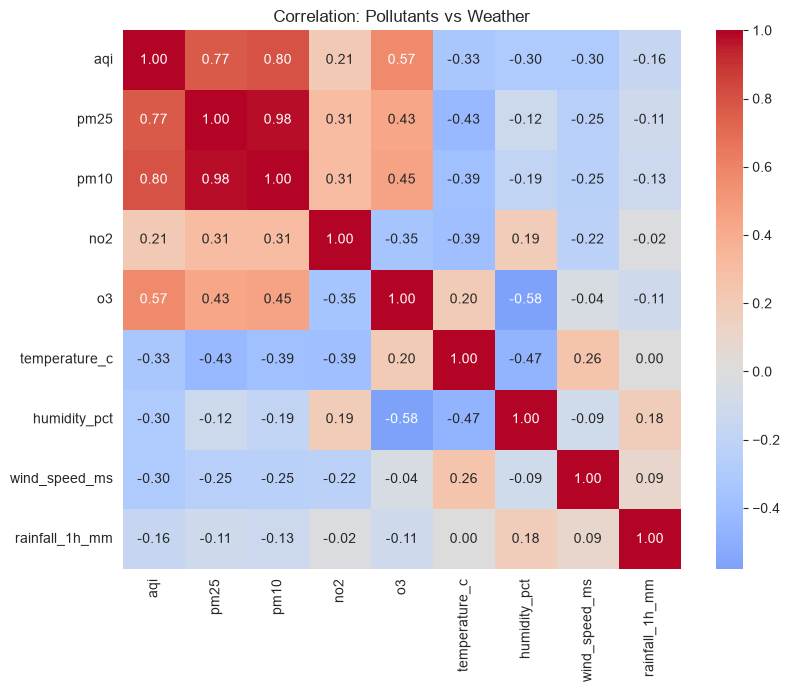

In [8]:
corr_cols = ["aqi", "pm25", "pm10", "no2", "o3",
             "temperature_c", "humidity_pct", "wind_speed_ms", "rainfall_1h_mm"]

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: Pollutants vs Weather")
plt.show()

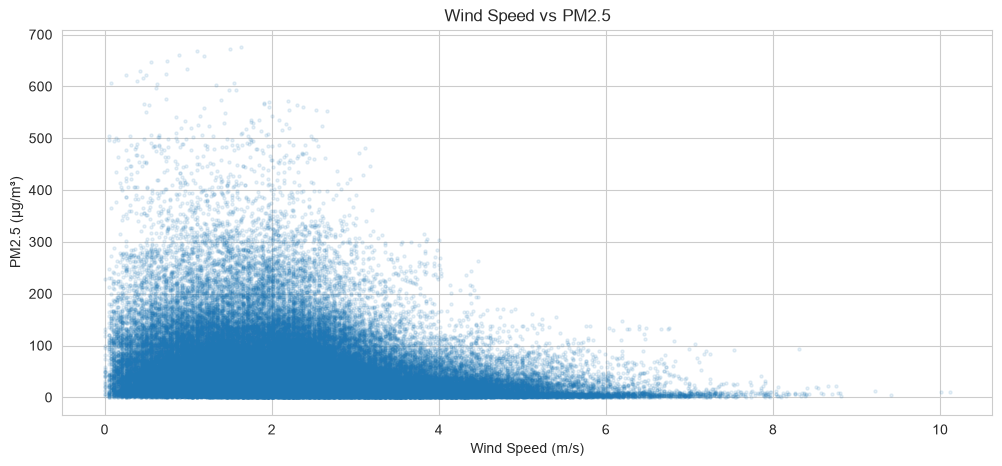

In [9]:
plt.scatter(df["wind_speed_ms"], df["pm25"], alpha=0.1, s=5)
plt.title("Wind Speed vs PM2.5")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

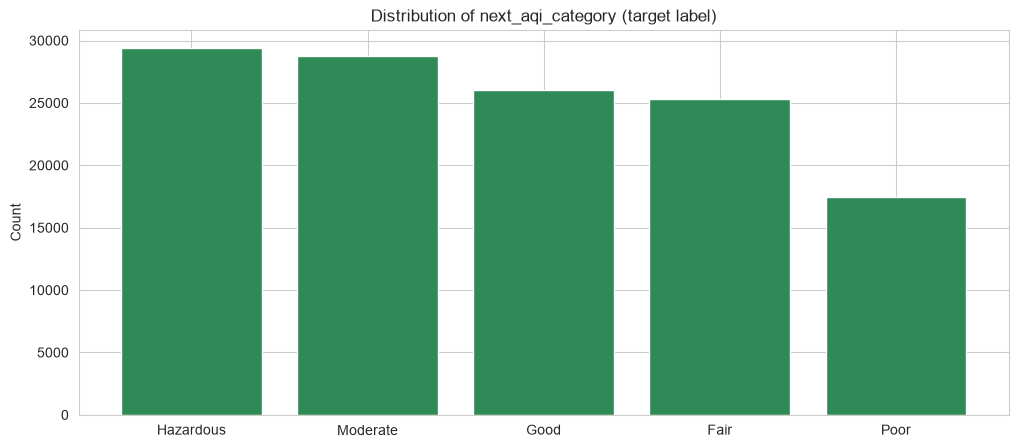

next_aqi_category
Hazardous    29388
Moderate     28794
Good         26042
Fair         25325
Poor         17462
Name: count, dtype: int64

In [10]:
label_counts = df["next_aqi_category"].value_counts()

plt.bar(label_counts.index, label_counts.values, color="seagreen")
plt.title("Distribution of next_aqi_category (target label)")
plt.ylabel("Count")
plt.show()

label_counts

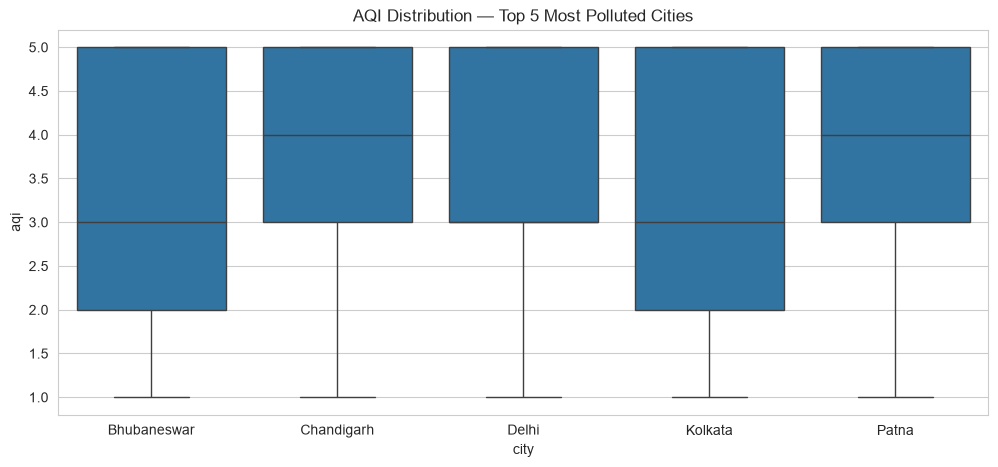

In [11]:
top5 = city_avg.head(5).index.tolist()

sns.boxplot(data=df[df["city"].isin(top5)], x="city", y="aqi")
plt.title("AQI Distribution — Top 5 Most Polluted Cities")
plt.show()

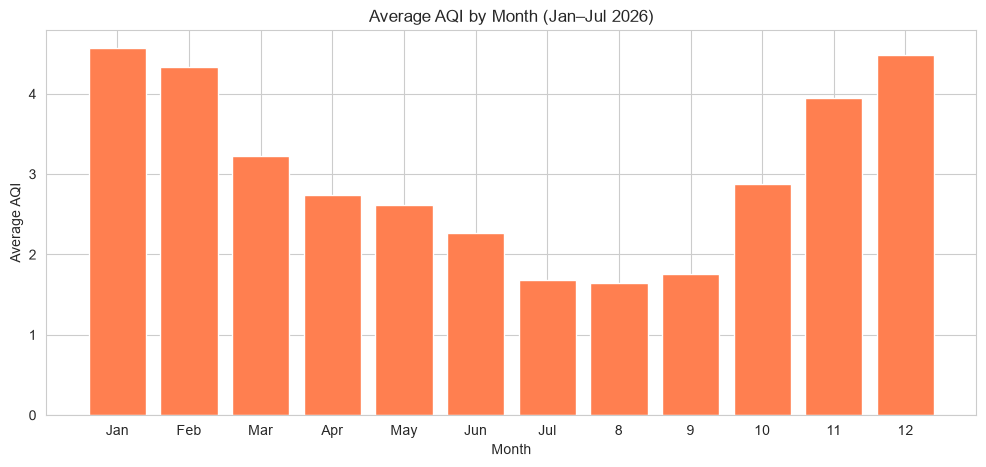

Jan    4.563793
Feb    4.334778
Mar    3.225552
Apr    2.736398
May    2.616923
Jun    2.268265
Jul    1.676230
8      1.645251
9      1.760278
10     2.873297
11     3.942500
12     4.484588
Name: aqi, dtype: float64

In [12]:
monthly_avg = df.groupby("month")["aqi"].mean()

month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun", 7:"Jul"}
monthly_avg.index = [month_names.get(m, str(m)) for m in monthly_avg.index]

plt.bar(monthly_avg.index, monthly_avg.values, color="coral")
plt.title("Average AQI by Month (Jan–Jul 2026)")
plt.ylabel("Average AQI")
plt.xlabel("Month")
plt.show()

monthly_avg

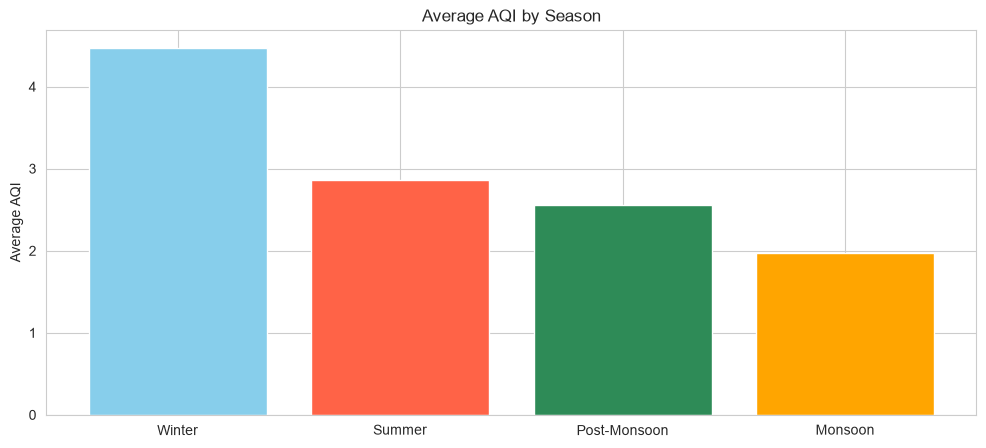

season
Winter          4.467549
Summer          2.862719
Post-Monsoon    2.550478
Monsoon         1.967223
Name: aqi, dtype: float64

In [13]:
def label_season(month):
    if month in [12, 1, 2]:   return "Winter"
    elif month in [3, 4, 5]:  return "Summer"
    elif month in [6, 7]:     return "Monsoon"
    else:                      return "Post-Monsoon"

df["season"] = df["month"].apply(label_season)

season_avg = df.groupby("season")["aqi"].mean().sort_values(ascending=False)

plt.bar(season_avg.index, season_avg.values, 
        color=["skyblue", "tomato", "seagreen", "orange"])
plt.title("Average AQI by Season")
plt.ylabel("Average AQI")
plt.show()

season_avg

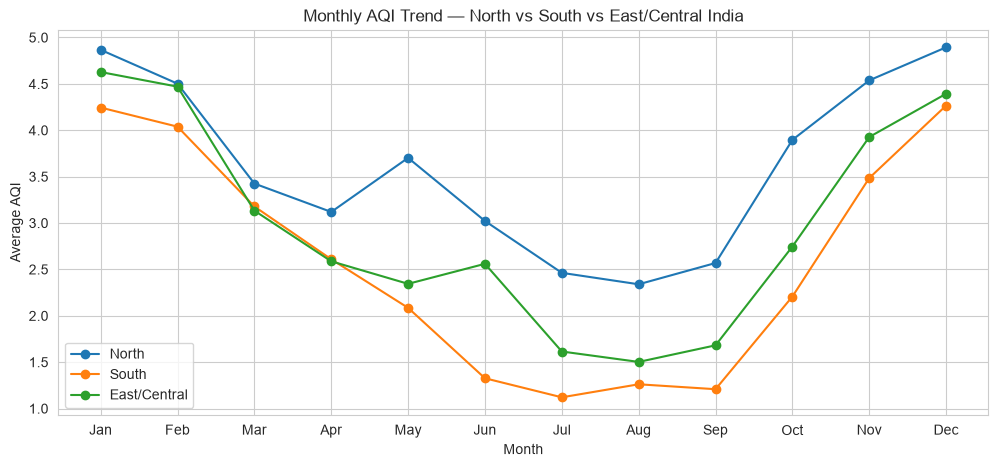

In [15]:
north = ["Delhi", "Patna", "Chandigarh", "Jaipur"]
south = ["Chennai", "Bengaluru", "Hyderabad", "Mumbai", "Pune"]

df["region"] = df["city"].apply(
    lambda x: "North" if x in north else ("South" if x in south else "East/Central")
)

region_monthly = df.groupby(["region", "month"])["aqi"].mean().reset_index()

# Automatically convert month numbers (1–12) to Jan, Feb, ..., Dec
region_monthly["month_name"] = pd.to_datetime(
    region_monthly["month"], format="%m"
).dt.strftime("%b")

for region in ["North", "South", "East/Central"]:
    subset = region_monthly[region_monthly["region"] == region]
    plt.plot(subset["month_name"], subset["aqi"], marker="o", label=region)

plt.title("Monthly AQI Trend — North vs South vs East/Central India")
plt.ylabel("Average AQI")
plt.xlabel("Month")
plt.legend()
plt.show()

Average AQI during monsoon months (Jun–Sep)  : 1.83
Average AQI during non-monsoon months         : 3.59
Average rainfall during monsoon (mm/hr)       : 0.303
Average rainfall during non-monsoon (mm/hr)   : 0.059


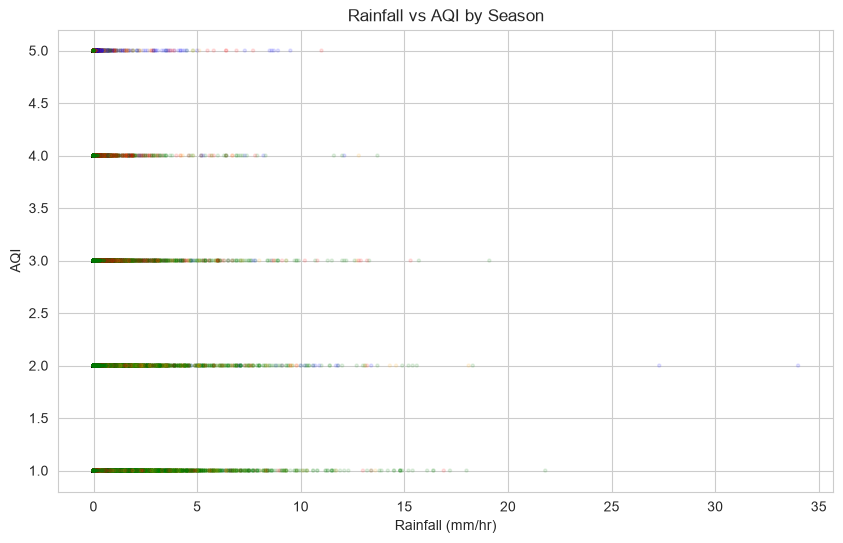

In [18]:
# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

# Add season column
df["season"] = df["month"].apply(get_season)

# Monsoon vs non-monsoon comparison
monsoon_months = df[df["month"].isin([6, 7, 8, 9])]
non_monsoon = df[~df["month"].isin([6, 7, 8, 9])]

print(f"Average AQI during monsoon months (Jun–Sep)  : {monsoon_months['aqi'].mean():.2f}")
print(f"Average AQI during non-monsoon months         : {non_monsoon['aqi'].mean():.2f}")
print(f"Average rainfall during monsoon (mm/hr)       : {monsoon_months['rainfall_1h_mm'].mean():.3f}")
print(f"Average rainfall during non-monsoon (mm/hr)   : {non_monsoon['rainfall_1h_mm'].mean():.3f}")

# Scatter plot: Rainfall vs AQI, colored by season
colors = df["season"].map({
    "Winter": "blue",
    "Summer": "red",
    "Monsoon": "green",
    "Post-Monsoon": "orange"
})

plt.figure(figsize=(10, 6))
plt.scatter(
    df["rainfall_1h_mm"],
    df["aqi"],
    c=colors,
    alpha=0.1,
    s=5
)

plt.title("Rainfall vs AQI by Season")
plt.xlabel("Rainfall (mm/hr)")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

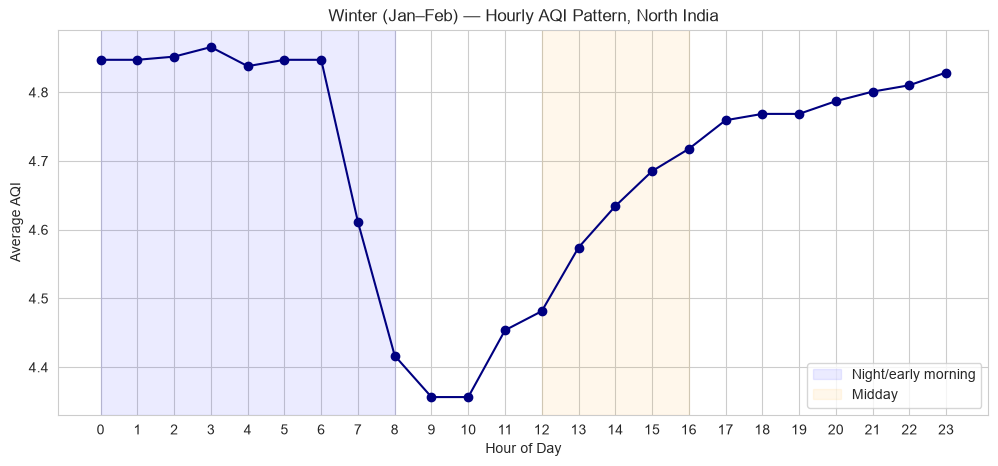

In [19]:
winter_north = df[
    (df["month"].isin([1, 2])) &
    (df["city"].isin(north))
]

winter_hourly = winter_north.groupby("hour")["aqi"].mean()

plt.plot(winter_hourly.index, winter_hourly.values, marker="o", color="navy")
plt.title("Winter (Jan–Feb) — Hourly AQI Pattern, North India")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.axvspan(0, 8, alpha=0.08, color="blue", label="Night/early morning")
plt.axvspan(12, 16, alpha=0.08, color="orange", label="Midday")
plt.legend()
plt.show()

In [20]:
city = "Ahmedabad"

check = df[df["city"] == city].sort_values("timestamp").tail(48)

print(check[["timestamp", "aqi"]])
print(check["aqi"].value_counts())

               timestamp  aqi
8453 2026-06-29 00:00:00    1
8454 2026-06-29 01:00:00    1
8455 2026-06-29 02:00:00    1
8456 2026-06-29 03:00:00    1
8457 2026-06-29 04:00:00    1
8458 2026-06-29 05:00:00    1
8459 2026-06-29 06:00:00    1
8460 2026-06-29 07:00:00    1
8461 2026-06-29 08:00:00    1
8462 2026-06-29 09:00:00    1
8463 2026-06-29 10:00:00    1
8464 2026-06-29 11:00:00    1
8465 2026-06-29 12:00:00    1
8466 2026-06-29 13:00:00    1
8467 2026-06-29 14:00:00    1
8468 2026-06-29 15:00:00    1
8469 2026-06-29 16:00:00    1
8470 2026-06-29 17:00:00    1
8471 2026-06-29 18:00:00    1
8472 2026-06-29 19:00:00    1
8473 2026-06-29 20:00:00    1
8474 2026-06-29 21:00:00    1
8475 2026-06-29 22:00:00    1
8476 2026-06-29 23:00:00    1
8477 2026-06-30 00:00:00    1
8478 2026-06-30 01:00:00    1
8479 2026-06-30 02:00:00    1
8480 2026-06-30 03:00:00    1
8481 2026-06-30 04:00:00    1
8482 2026-06-30 05:00:00    1
8483 2026-06-30 06:00:00    1
8484 2026-06-30 07:00:00    1
8485 2026-

In [21]:
city = "Pune"

check = df[df["city"] == city].sort_values("timestamp").tail(48)

print(check[["timestamp", "aqi"]])
print(check["aqi"].value_counts())

                 timestamp  aqi
118486 2026-06-29 00:00:00    1
118487 2026-06-29 01:00:00    1
118488 2026-06-29 02:00:00    1
118489 2026-06-29 03:00:00    1
118490 2026-06-29 04:00:00    1
118491 2026-06-29 05:00:00    1
118492 2026-06-29 06:00:00    1
118493 2026-06-29 07:00:00    1
118494 2026-06-29 08:00:00    1
118495 2026-06-29 09:00:00    1
118496 2026-06-29 10:00:00    1
118497 2026-06-29 11:00:00    1
118498 2026-06-29 12:00:00    1
118499 2026-06-29 13:00:00    1
118500 2026-06-29 14:00:00    1
118501 2026-06-29 15:00:00    1
118502 2026-06-29 16:00:00    1
118503 2026-06-29 17:00:00    1
118504 2026-06-29 18:00:00    1
118505 2026-06-29 19:00:00    1
118506 2026-06-29 20:00:00    1
118507 2026-06-29 21:00:00    1
118508 2026-06-29 22:00:00    1
118509 2026-06-29 23:00:00    1
118510 2026-06-30 00:00:00    1
118511 2026-06-30 01:00:00    1
118512 2026-06-30 02:00:00    1
118513 2026-06-30 03:00:00    1
118514 2026-06-30 04:00:00    1
118515 2026-06-30 05:00:00    1
118516 2

In [22]:
# === Prophet Validation Check ===

cities = ["Ahmedabad", "Pune"]

for city in cities:
    print("=" * 80)
    print(f"CITY: {city}")
    print("=" * 80)

    city_df = (
        df[df["city"] == city]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # -------------------------------
    # Basic information
    # -------------------------------
    print(f"Total rows: {len(city_df)}")
    print(f"Date range: {city_df['timestamp'].min()}  -->  {city_df['timestamp'].max()}")

    # -------------------------------
    # AQI distribution (entire year)
    # -------------------------------
    print("\nAQI distribution (whole dataset):")
    print(city_df["aqi"].value_counts().sort_index())

    # -------------------------------
    # Last 200 hours AQI distribution
    # -------------------------------
    print("\nAQI distribution (last 200 hours):")
    print(city_df.tail(200)["aqi"].value_counts().sort_index())

    # -------------------------------
    # Last 48 hours AQI distribution
    # -------------------------------
    print("\nAQI distribution (last 48 hours):")
    print(city_df.tail(48)["aqi"].value_counts().sort_index())

    # -------------------------------
    # Last 48 hours detailed values
    # -------------------------------
    print("\nLast 48 hours:")
    print(
        city_df.tail(48)[
            [
                "timestamp",
                "aqi",
                "pm25",
                "pm10",
                "temperature_c",
                "humidity_pct",
                "wind_speed_ms",
                "rainfall_1h_mm",
            ]
        ]
    )

    # -------------------------------
    # PM2.5 statistics
    # -------------------------------
    print("\nPM2.5 statistics:")
    print(city_df["pm25"].describe())

    # -------------------------------
    # AQI transitions
    # -------------------------------
    print("\nAQI transitions:")
    print(city_df["aqi"].diff().value_counts().sort_index())

    # -------------------------------
    # Last 30 days AQI
    # -------------------------------
    print("\nLast 30 days AQI counts:")
    print(city_df.tail(24 * 30)["aqi"].value_counts().sort_index())

    print("\n")

CITY: Ahmedabad
Total rows: 8501
Date range: 2025-07-01 19:00:00  -->  2026-06-30 23:00:00

AQI distribution (whole dataset):
aqi
1    2244
2    1672
3    1775
4    1019
5    1791
Name: count, dtype: int64

AQI distribution (last 200 hours):
aqi
1    147
2     53
Name: count, dtype: int64

AQI distribution (last 48 hours):
aqi
1    48
Name: count, dtype: int64

Last 48 hours:
               timestamp  aqi  pm25   pm10  temperature_c  humidity_pct  \
8453 2026-06-29 00:00:00    1  4.39  12.28           30.0          68.0   
8454 2026-06-29 01:00:00    1  4.27  12.08           29.9          68.0   
8455 2026-06-29 02:00:00    1  4.13  11.71           30.4          66.0   
8456 2026-06-29 03:00:00    1  3.92  10.94           31.2          63.0   
8457 2026-06-29 04:00:00    1  3.23   8.58           32.6          56.0   
8458 2026-06-29 05:00:00    1  2.70   6.74           34.1          50.0   
8459 2026-06-29 06:00:00    1  2.73   6.21           35.6          44.0   
8460 2026-06-29 07:00

In [23]:
for city in ["Ahmedabad", "Pune"]:
    city_df = df[df["city"] == city].sort_values("timestamp")

    print(f"\n{city}")
    print("Unique AQI in last 7 days:", city_df.tail(24 * 7)["aqi"].unique())
    print("Unique AQI in last 30 days:", city_df.tail(24 * 30)["aqi"].unique())


Ahmedabad
Unique AQI in last 7 days: [1 2]
Unique AQI in last 30 days: [1 2 3]

Pune
Unique AQI in last 7 days: [1]
Unique AQI in last 30 days: [1 2]
